In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load synthetic data có causal effect
df = pd.read_csv('../data/processed/synthetic_uplift_data.csv')

print(f"Shape: {df.shape}")
print(f"\nSegment distribution:")
print(df['segment_true'].value_counts(normalize=True).round(3))
print(f"\nOverall churn rate: {df['churned'].mean():.3f}")
print(f"Treatment rate: {df['treated'].mean():.3f}")

Shape: (5000, 14)

Segment distribution:
segment_true
Sure_Thing      0.338
Persuadable     0.254
Sleeping_Dog    0.205
Lost_Cause      0.203
Name: proportion, dtype: float64

Overall churn rate: 0.428
Treatment rate: 0.491


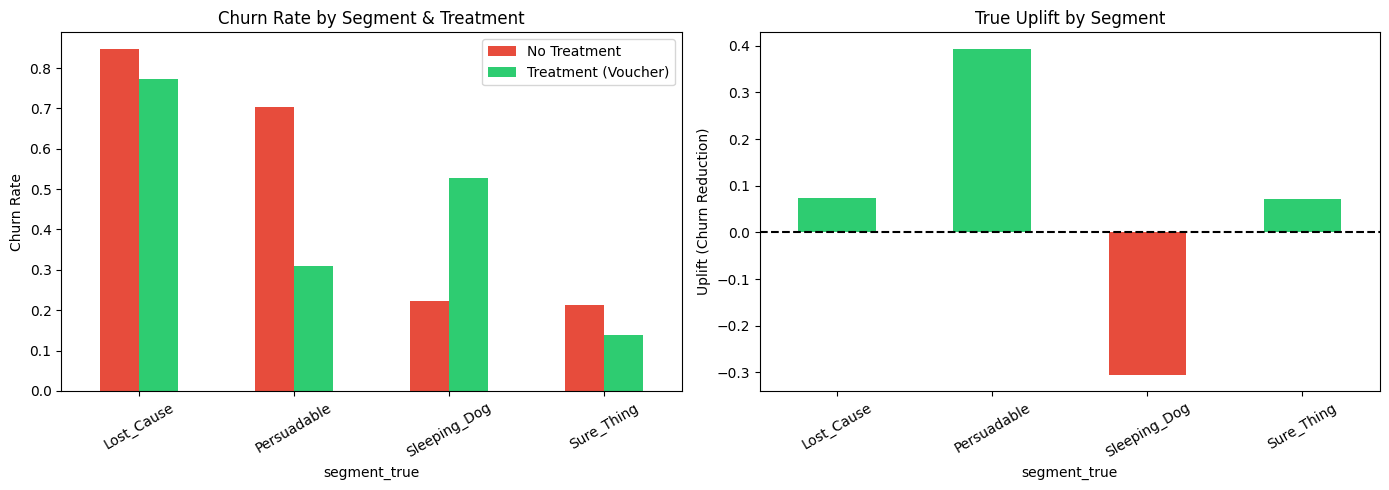


=== TRUE TREATMENT EFFECT ===
              No Treatment  Treatment (Voucher)  Uplift
segment_true                                           
Lost_Cause           0.846                0.772   0.075
Persuadable          0.704                0.310   0.394
Sleeping_Dog         0.222                0.527  -0.305
Sure_Thing           0.212                0.140   0.072


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by segment + treatment
effect = df.groupby(['segment_true', 'treated'])['churned'].mean().unstack()
effect.columns = ['No Treatment', 'Treatment (Voucher)']
effect['Uplift'] = effect['No Treatment'] - effect['Treatment (Voucher)']

effect[['No Treatment', 'Treatment (Voucher)']].plot(
    kind='bar', ax=axes[0], color=['#E74C3C', '#2ECC71'], rot=30
)
axes[0].set_title('Churn Rate by Segment & Treatment')
axes[0].set_ylabel('Churn Rate')
axes[0].legend()

# Uplift by segment
colors = ['#2ECC71' if x > 0 else '#E74C3C' for x in effect['Uplift']]
effect['Uplift'].plot(kind='bar', ax=axes[1], color=colors, rot=30)
axes[1].set_title('True Uplift by Segment')
axes[1].set_ylabel('Uplift (Churn Reduction)')
axes[1].axhline(y=0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('../data/processed/true_uplift_by_segment.png', dpi=150)
plt.show()

print("\n=== TRUE TREATMENT EFFECT ===")
print(effect.round(3))

In [3]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb

FEATURE_COLS = ['tenure', 'monthly_charges', 'contract_type', 'service_count',
                'clv_proxy', 'senior_citizen', 'has_partner', 'digital_engagement',
                'charge_per_month' if 'charge_per_month' in df.columns else 'monthly_charges']

# Dùng các feature có trong data
FEATURE_COLS = [c for c in ['tenure', 'monthly_charges', 'contract_type',
                             'service_count', 'clv_proxy', 'senior_citizen',
                             'has_partner', 'digital_engagement'] if c in df.columns]

TREATMENT_COL = 'treated'
OUTCOME_COL = 'churned'

X = df[FEATURE_COLS]
treatment = df[TREATMENT_COL]
y = df[OUTCOME_COL]

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, treatment, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Features: {FEATURE_COLS}")

Train: (4000, 8)
Test:  (1000, 8)
Features: ['tenure', 'monthly_charges', 'contract_type', 'service_count', 'clv_proxy', 'senior_citizen', 'has_partner', 'digital_engagement']


In [4]:
# T-Learner: train 2 models riêng biệt
# Model T1: chỉ train trên treated group
# Model T0: chỉ train trên control group
# Uplift = T1.predict(x) - T0.predict(x)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'verbose': -1,
    'random_state': 42,
}

# Model T1 — treated group (received voucher)
treated_mask_train = t_train == 1
X_treated = X_train[treated_mask_train]
y_treated = y_train[treated_mask_train]

model_t1 = lgb.LGBMClassifier(**lgb_params, n_estimators=200)
model_t1.fit(X_treated, y_treated)

# Model T0 — control group (no voucher)
control_mask_train = t_train == 0
X_control = X_train[control_mask_train]
y_control = y_train[control_mask_train]

model_t0 = lgb.LGBMClassifier(**lgb_params, n_estimators=200)
model_t0.fit(X_control, y_control)

print(f"T1 model trained on {treated_mask_train.sum()} treated users ✅")
print(f"T0 model trained on {control_mask_train.sum()} control users ✅")

T1 model trained on 1967 treated users ✅
T0 model trained on 2033 control users ✅


In [5]:
# Uplift = P(churn | no treatment) - P(churn | treatment)
# Uplift dương = voucher giúp giảm churn → nên target
# Uplift âm = voucher làm tăng churn (Sleeping Dog) → tránh

p_churn_no_treatment = model_t0.predict_proba(X_test)[:, 1]
p_churn_with_treatment = model_t1.predict_proba(X_test)[:, 1]
uplift_scores = p_churn_no_treatment - p_churn_with_treatment

df_test = X_test.copy()
df_test['uplift_score'] = uplift_scores
df_test['p_churn_control'] = p_churn_no_treatment
df_test['p_churn_treated'] = p_churn_with_treatment
df_test['segment_true'] = df.loc[X_test.index, 'segment_true'].values
df_test['churned'] = y_test.values

print("=== UPLIFT SCORE STATISTICS ===")
print(df_test['uplift_score'].describe().round(4))
print(f"\nPositive uplift (should target): {(uplift_scores > 0).sum()} users")
print(f"Negative uplift (Sleeping Dogs): {(uplift_scores < 0).sum()} users")

=== UPLIFT SCORE STATISTICS ===
count    1000.0000
mean        0.0617
std         0.3170
min        -0.8015
25%        -0.1140
50%         0.0754
75%         0.2568
max         0.8829
Name: uplift_score, dtype: float64

Positive uplift (should target): 622 users
Negative uplift (Sleeping Dogs): 378 users


In [6]:
def assign_uplift_segment(row, uplift_col='uplift_score',
                           churn_col='p_churn_control',
                           uplift_threshold_high=0.70,
                           uplift_threshold_low=0.30,
                           churn_threshold=0.50):
    """
    Percentile-based segmentation — không dùng hardcoded thresholds
    """
    uplift_pct = row['uplift_percentile']
    churn_prob = row[churn_col]

    if uplift_pct >= uplift_threshold_high and churn_prob >= churn_threshold:
        return 'Persuadable'
    elif uplift_pct < uplift_threshold_low and row[uplift_col] < 0:
        return 'Sleeping_Dog'
    elif churn_prob >= churn_threshold and uplift_pct < uplift_threshold_high:
        return 'Lost_Cause'
    else:
        return 'Sure_Thing'

# Tính percentile rank
df_test['uplift_percentile'] = df_test['uplift_score'].rank(pct=True)

df_test['predicted_segment'] = df_test.apply(assign_uplift_segment, axis=1)

print("=== PREDICTED SEGMENT DISTRIBUTION ===")
print(df_test['predicted_segment'].value_counts())
print()
print("=== SEGMENT ACCURACY vs TRUE SEGMENT ===")
from sklearn.metrics import classification_report
print(classification_report(
    df_test['segment_true'],
    df_test['predicted_segment'],
    zero_division=0
))

=== PREDICTED SEGMENT DISTRIBUTION ===
predicted_segment
Sleeping_Dog    299
Sure_Thing      282
Persuadable     243
Lost_Cause      176
Name: count, dtype: int64

=== SEGMENT ACCURACY vs TRUE SEGMENT ===
              precision    recall  f1-score   support

  Lost_Cause       0.61      0.55      0.58       195
 Persuadable       0.74      0.66      0.70       272
Sleeping_Dog       0.65      0.89      0.75       216
  Sure_Thing       0.87      0.78      0.82       317

    accuracy                           0.73      1000
   macro avg       0.72      0.72      0.71      1000
weighted avg       0.74      0.73      0.72      1000



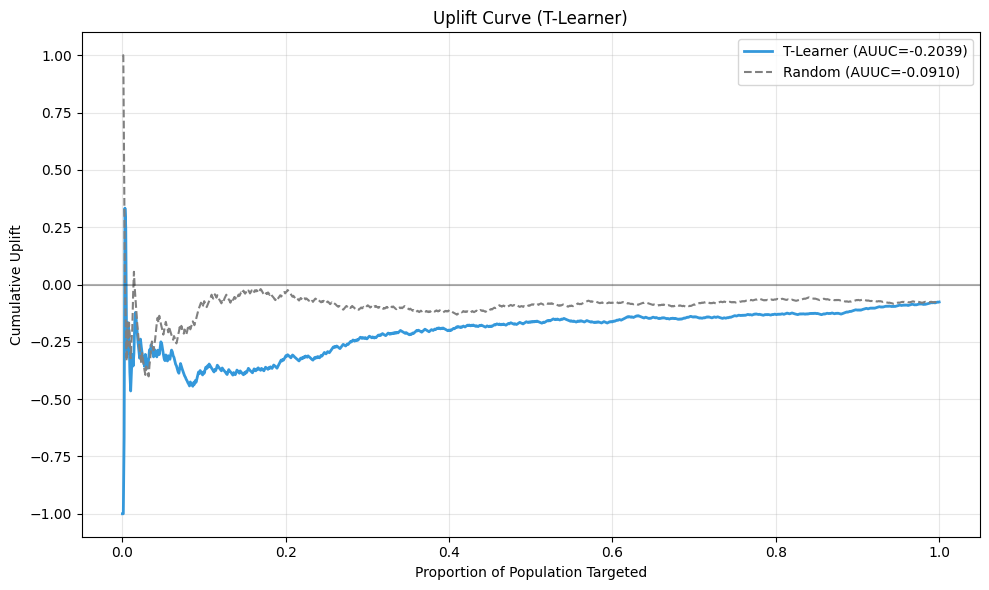

AUUC T-Learner: -0.2039
AUUC Random:    -0.0910
Improvement:    -0.1129


In [9]:
def compute_auuc(y_true, uplift_scores, treatment):
    """
    Standard AUUC calculation
    Sort by uplift descending → tính cumulative uplift gain
    """
    df_curve = pd.DataFrame({
        'y': y_true,
        'uplift': uplift_scores,
        'treatment': treatment
    }).sort_values('uplift', ascending=False).reset_index(drop=True)

    n = len(df_curve)
    n_treated_total = treatment.sum()
    n_control_total = (1 - treatment).sum()

    cumulative_uplift = []
    treated_outcomes = 0
    control_outcomes = 0
    n_treated_seen = 0
    n_control_seen = 0

    for i, row in df_curve.iterrows():
        if row['treatment'] == 1:
            n_treated_seen += 1
            treated_outcomes += row['y']
        else:
            n_control_seen += 1
            control_outcomes += row['y']

        rate_treated = treated_outcomes / n_treated_seen if n_treated_seen > 0 else 0
        rate_control = control_outcomes / n_control_seen if n_control_seen > 0 else 0
        cumulative_uplift.append(rate_treated - rate_control)

    cumulative_uplift = np.array(cumulative_uplift)
    auuc = np.trapz(cumulative_uplift) / n
    return cumulative_uplift, auuc

# Random baseline — shuffle uplift scores
np.random.seed(42)
random_scores = np.random.permutation(uplift_scores)
random_curve, auuc_random = compute_auuc(y_test.values, random_scores, t_test.values)
model_curve, auuc = compute_auuc(y_test.values, uplift_scores, t_test.values)

x_axis = np.linspace(0, 1, len(model_curve))

plt.figure(figsize=(10, 6))
plt.plot(x_axis, model_curve,
         label=f'T-Learner (AUUC={auuc:.4f})', color='#3498DB', linewidth=2)
plt.plot(x_axis, random_curve,
         label=f'Random (AUUC={auuc_random:.4f})', color='gray', linestyle='--')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Proportion of Population Targeted')
plt.ylabel('Cumulative Uplift')
plt.title('Uplift Curve (T-Learner)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/uplift_curve.png', dpi=150)
plt.show()

print(f"AUUC T-Learner: {auuc:.4f}")
print(f"AUUC Random:    {auuc_random:.4f}")
print(f"Improvement:    {auuc - auuc_random:.4f}")

In [8]:
import joblib, mlflow

joblib.dump(model_t0, '../data/processed/models/uplift_t0.pkl')
joblib.dump(model_t1, '../data/processed/models/uplift_t1.pkl')

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('churn-prediction')

with mlflow.start_run(run_name='uplift_t_learner'):
    mlflow.log_metric('auuc', auuc)
    mlflow.log_metric('auuc_random', auuc_random)
    mlflow.log_metric('auuc_improvement', auuc - auuc_random)
    mlflow.log_artifact('../data/processed/uplift_curve.png')
    mlflow.log_artifact('../data/processed/true_uplift_by_segment.png')

df_test.to_csv('../data/processed/uplift_predictions.csv', index=False)
print("Uplift models saved ✅")
print(f"MLflow logged ✅")

🏃 View run uplift_t_learner at: http://localhost:5000/#/experiments/1/runs/9d56f0ab6f2d41aa8fe9695388b405c8
🧪 View experiment at: http://localhost:5000/#/experiments/1
Uplift models saved ✅
MLflow logged ✅
